# Notebook 10 — Visualize Clusters with PCA

## Objective

In Notebook 09 we used K-Means clustering to group astronomical objects according to their measured physical properties.

However, our machine learning model used eight-dimensional feature vectors, which cannot be visualized directly.

In this notebook we use **Principal Component Analysis (PCA)** to project those eight features into two dimensions while preserving as much of the original variance as possible.

We will:

- Load the machine learning feature table
- Standardize the features
- Perform Principal Component Analysis (PCA)
- Visualize the galaxy clusters in two dimensions
- Determine how much information is preserved by the first two principal components
- Identify which astronomical features contribute most strongly to each principal component

By the end of this notebook we will understand **why the clusters appear where they do**, providing our first interpretation of the AI's representation of the Hubble Ultra Deep Field.

In [1]:
# Cell 2 - Import libraries ==============================

import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Cell 3 - Load the feature table created in Notebook 08 ====

catalog = Table.read("../data/catalogs/clustered_galaxies.ecsv")

print("=" * 60)
print("Machine Learning Dataset")
print("=" * 60)
print(f"Objects : {len(catalog)}")
print(f"Columns : {len(catalog.colnames)}")

catalog[:5]

Machine Learning Dataset
Objects : 95
Columns : 9


segment_flux,area,semimajor_axis,semiminor_axis,eccentricity,orientation,axis_ratio,flux_per_pixel,cluster
,pix2,pix,pix,,deg,pix,,
float64,float64,float64,float64,float64,float64,float64,float64,int32
103.97923684120178,24.0,2.1532985095548427,1.4546436878746936,0.7373214628932244,59.68625869106634,1.4802927531352494,4.332468201716741,2
19.497517228126526,16.0,1.0425375485147124,0.8473819282730207,0.5825329240047639,30.763603254853948,1.2303042037247858,1.2185948267579079,2
31.58135676383972,16.0,0.8541513400365031,0.7580456582502352,0.4608385055033623,277.7009772993434,1.1267808617334536,1.9738347977399826,0
6.465743601322174,6.0,0.6440643877584695,0.5514238892637224,0.516706370668758,294.4995327788689,1.1680023305091904,1.0776239335536957,0
24.018874406814575,32.0,2.2941649471403283,1.4005674373639603,0.7920230641969821,303.90657994640236,1.6380253359725598,0.7505898252129555,0


In [3]:
# Cell 4 — Separate Features and Cluster Labels ============

# Machine learning features

feature_columns = [
    "segment_flux",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "eccentricity",
    "orientation",
    "axis_ratio",
    "flux_per_pixel"
]

X = np.column_stack([catalog[col] for col in feature_columns])

print("Feature matrix shape:", X.shape)

# Cluster labels from Notebook 09
clusters = catalog["cluster"]

print("Cluster labels:", np.unique(clusters))

Feature matrix shape: (95, 8)
Cluster labels: [0 1 2]


In [4]:
# Cell 5 - Standardize the Features =======================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=" * 60)
print("Standardized Feature Matrix")
print("=" * 60)

print("Shape:", X_scaled.shape)

print("\nMean of first feature :", X_scaled[:, 0].mean())
print("Std of first feature  :", X_scaled[:, 0].std())

Standardized Feature Matrix
Shape: (95, 8)

Mean of first feature : 2.8339903523326366e-17
Std of first feature  : 0.9999999999999999


In [5]:
# Cell 6 - Perform Principal Component Analysis ================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("=" * 60)
print("Principal Component Analysis")
print("=" * 60)
print("Transformed feature matrix shape:", X_pca.shape)

Principal Component Analysis
Transformed feature matrix shape: (95, 2)


In [6]:
# Cell 7 - Explained Variance ================================

explained = pca.explained_variance_ratio_

print("=" * 60)
print("Explained Variance")
print("=" * 60)

for i, value in enumerate(explained):
    print(f"Principal Component {i+1}: {value:.2%}")

print()
print(f"Total Variance Explained: {explained.sum():.2%}")

Explained Variance
Principal Component 1: 54.03%
Principal Component 2: 19.36%

Total Variance Explained: 73.39%


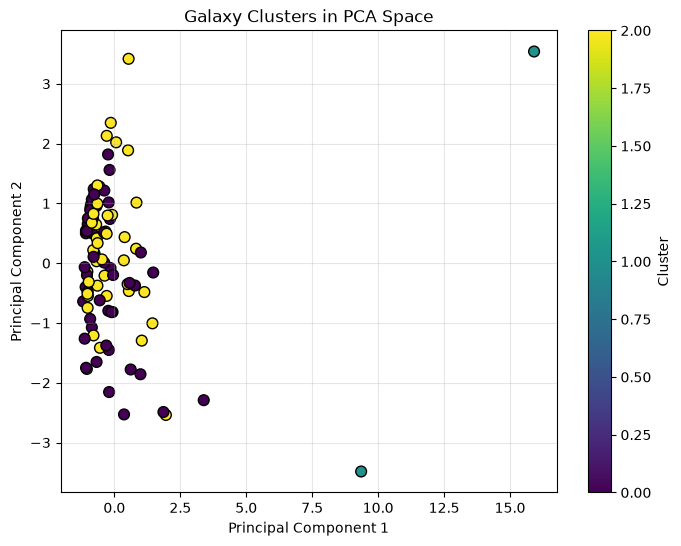

In [7]:
# Cell 8 - PCA Visualization =================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=60,
    edgecolor="black"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Galaxy Clusters in PCA Space")

plt.grid(alpha=0.3)

plt.colorbar(scatter, label="Cluster")

plt.show()

In [8]:
# Cell 9 - PCA Loading Matrix ================================

loadings = pca.components_.T

print("=" * 60)
print("PCA Feature Loadings")
print("=" * 60)

for i, feature in enumerate(feature_columns):
    print(
        f"{feature:18s} "
        f"PC1 = {loadings[i,0]:8.3f}   "
        f"PC2 = {loadings[i,1]:8.3f}"
    )

PCA Feature Loadings
segment_flux       PC1 =    0.461   PC2 =   -0.025
area               PC1 =    0.459   PC2 =   -0.141
semimajor_axis     PC1 =    0.452   PC2 =    0.129
semiminor_axis     PC1 =    0.319   PC2 =   -0.473
eccentricity       PC1 =    0.099   PC2 =    0.641
orientation        PC1 =   -0.096   PC2 =   -0.120
axis_ratio         PC1 =    0.332   PC2 =    0.519
flux_per_pixel     PC1 =    0.376   PC2 =   -0.211


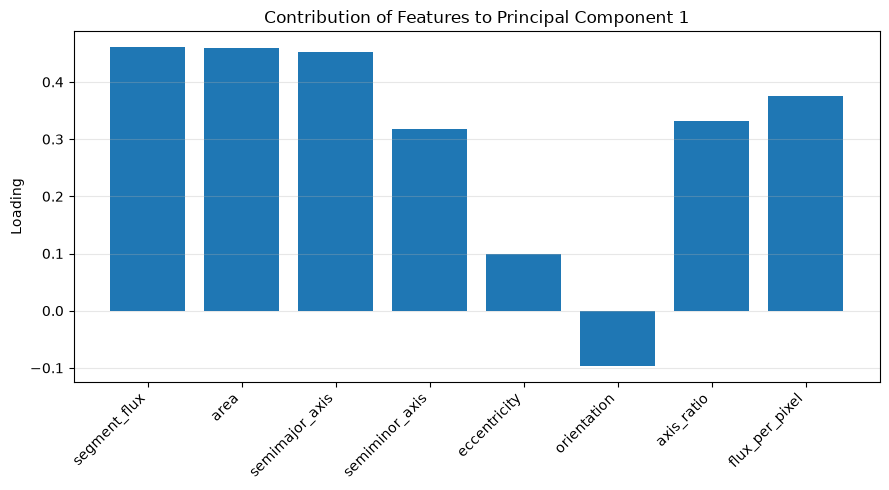

In [9]:
# Cell 10 - Feature Contributions to PC1 ======================

plt.figure(figsize=(9,5))

plt.bar(feature_columns, loadings[:,0])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Loading")

plt.title("Contribution of Features to Principal Component 1")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [10]:
# Cell 11 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 10_visualize_clusters_with_pca.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 10_visualize_clusters_with_pca.ipynb
Completed : 2026-07-27 15:49
